# Обучение диффузионной модели

Ноутбук реализует обучение модели на примере [туториала Hugging Face](https://huggingface.co/docs/diffusers/tutorials/basic_training). 
Используются `UNet2DModel`, `DDPMScheduler`, а также `DDPMPipeline` для оценки.

In [1]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler, DDPMPipeline
from diffusers.optimization import get_cosine_schedule_with_warmup
from datasets import load_dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import time

## 1. Конфигурация и данные

In [2]:
config = {
    "image_size": 64,
    "train_batch_size": 16,
    "eval_batch_size": 16,
    "num_epochs": 500,
    "learning_rate": 1e-4,
    "lr_warmup_steps": 500,
    "num_train_timesteps": 1000,
    "save_image_epochs": 100,
    "save_model_epochs": 100,
    "device": "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
}

preprocess = transforms.Compose([
    transforms.Resize((config["image_size"], config["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataset = load_dataset("huggan/few-shot-cat", split="train")

def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)
train_dataloader = DataLoader(dataset, batch_size=config["train_batch_size"], shuffle=True)

print(f"Устройство: {config['device']}")
print(f"Размер датасета: {len(dataset)}")

Repo card metadata block was not found. Setting CardData to empty.


Устройство: mps
Размер датасета: 160


## 2. Пояснения к модели и процессам

### Почему используется MSE Loss?
В диффузионных моделях мы обучаем нейросеть предсказывать шум $\epsilon$, который был добавлен к оригинальному изображению $x_0$ для получения зашумленного изображения $x_t$. Минимизация MSE между истинным шумом и предсказанным сетью шумом $\hat{\epsilon}_\theta(x_t, t)$  обоснована теоретически тем, что если сеть идеально предсказывает шум, она может идеально его отнять и восстановить картинку.

### Прямой процесс (Forward Process)
Это процесс постепенного превращения данных в шум. На каждом шаге $t$ мы добавляем небольшую порцию Гауссовского шума. Благодаря свойствам Гауссовского распределения мы можем получить зашумленное изображение на любом шаге $t$ напрямую из $x_0$, не проходя все промежуточные шаги.

### Обратный процесс (Reverse Process)
Это процесс генерации. Мы начинаем с чистого шума $x_T$ и итеративно используем обученную модель для предсказания и удаления шума, шаг за шагом восстанавливая структуру изображения. DDPM делает это стохастически, а DDIM — детерминированно и быстрее.

## 3. Модель, планировщик и оптимизатор

In [3]:
model = UNet2DModel(
    sample_size=config["image_size"],
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 128, 256, 256, 512, 512),
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
)
model.to(config["device"])

noise_scheduler = DDPMScheduler(num_train_timesteps=config["num_train_timesteps"], beta_schedule="linear")
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config["lr_warmup_steps"],
    num_training_steps=(len(train_dataloader) * config["num_epochs"]),
)

## 4. Обучение и оценка

In [4]:
def evaluate(config, epoch, model, noise_scheduler):
    pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
    # генератор обязан быть на CPU — иначе иногда вылетает ошибка
    gen_device = "cpu" if config["device"] == "mps" else config["device"]
    generator = torch.Generator(device=gen_device).manual_seed(42)
    
    images = pipeline(
        batch_size=config["eval_batch_size"],
        generator=generator,
    ).images

    cols, rows = 4, 4
    w, h = images[0].size
    grid = Image.new("RGB", (cols * w, rows * h))
    for i, img in enumerate(images):
        grid.paste(img, (i % cols * w, i // cols * h))
    
    os.makedirs("samples_hf", exist_ok=True)
    grid.save(f"samples_hf/epoch_{epoch+1}.png")
    plt.figure(figsize=(8, 8))
    plt.imshow(grid)
    plt.title(f"Эпоха {epoch+1}")
    plt.axis("off")
    plt.show()

def train_loop(config, model, noise_scheduler, optimizer, lr_scheduler, train_dataloader):
    losses = []
    os.makedirs("checkpoints_hf", exist_ok=True)

    for epoch in range(config["num_epochs"]):
        model.train()
        progress_bar = tqdm(total=len(train_dataloader))
        progress_bar.set_description(f"Эпоха {epoch}")
        
        epoch_losses = []
        for step, batch in enumerate(train_dataloader):
            clean_images = batch["images"].to(config["device"])
            noise = torch.randn(clean_images.shape).to(clean_images.device)
            bs = clean_images.shape[0]
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device).long()

            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
            noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
            loss = F.mse_loss(noise_pred, noise)
            
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

            progress_bar.update(1)
            progress_bar.set_postfix(loss=loss.item())
            epoch_losses.append(loss.item())
        
        losses.append(sum(epoch_losses) / len(epoch_losses))
        
        if (epoch + 1) % config["save_model_epochs"] == 0:
            torch.save(model.state_dict(), f"checkpoints_hf/model_epoch_{epoch+1}.pt")
        if (epoch + 1) % config["save_image_epochs"] == 0:
            evaluate(config, epoch, model, noise_scheduler)

    return losses

## 5. Запуск

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

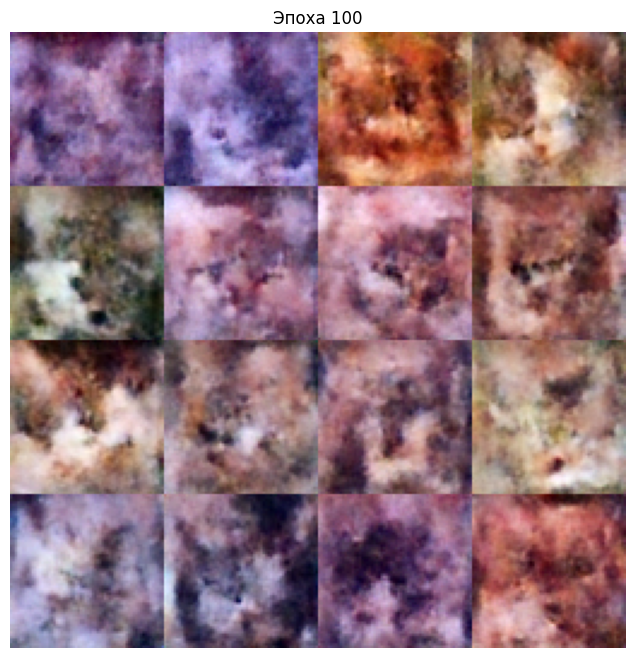

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

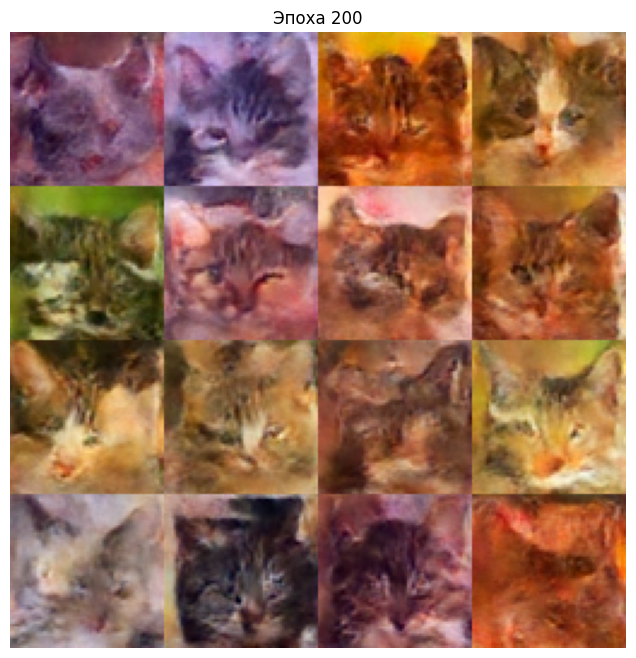

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

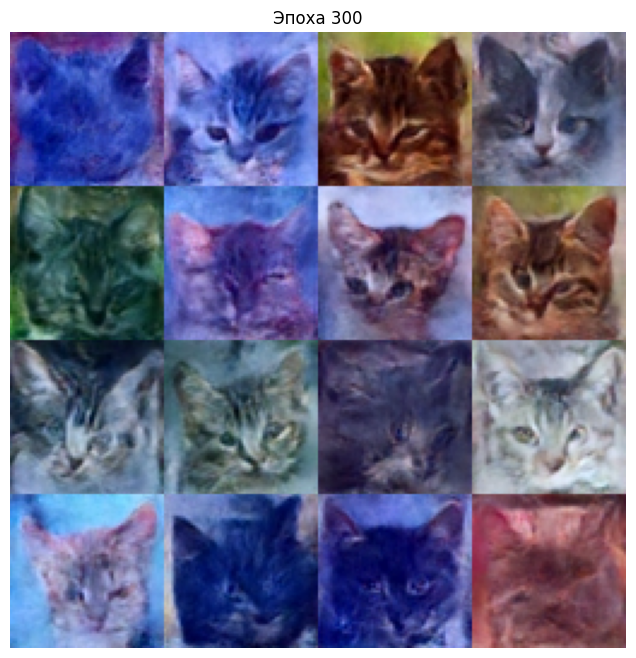

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

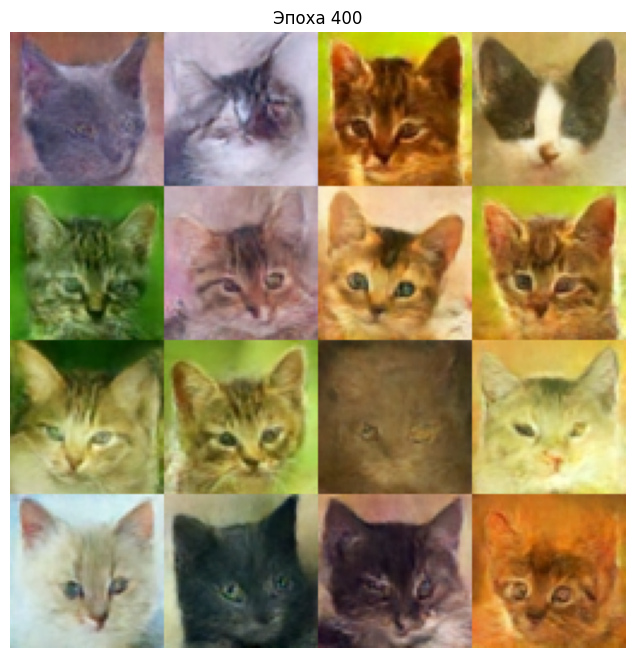

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

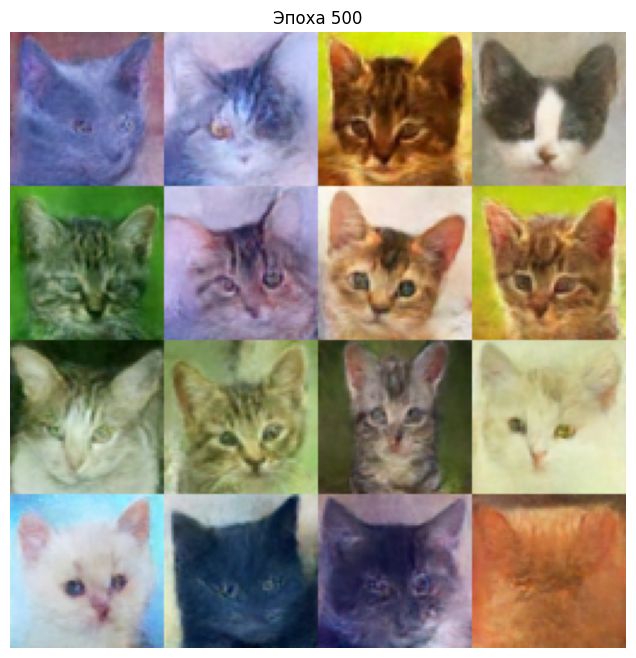

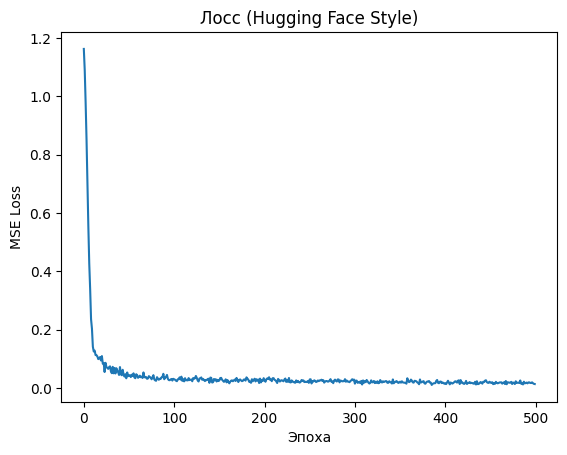

In [5]:
losses = train_loop(config, model, noise_scheduler, optimizer, lr_scheduler, train_dataloader)
plt.plot(losses)
plt.title("Лосс (Hugging Face Style)")
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.show()

## 6. Сравнение DDPM и DDIM

In [6]:
def sample_and_time(model, scheduler_class, num_steps, config, beta_schedule="linear"):
    scheduler = scheduler_class(num_train_timesteps=1000, beta_schedule=beta_schedule)
    pipeline = DDPMPipeline(unet=model, scheduler=scheduler).to(config["device"])
    
    start = time.time()
    images = pipeline(batch_size=4, num_inference_steps=num_steps).images
    end = time.time()
    
    return images, end - start

print("DDPM (1000 шагов)... ")
imgs_ddpm, t_ddpm = sample_and_time(model, DDPMScheduler, 1000, config)
print(f"Время: {t_ddpm:.2f}с")

print("DDIM (50 шагов)... ")
imgs_ddim, t_ddim = sample_and_time(model, DDIMScheduler, 50, config)
print(f"Время: {t_ddim:.2f}с")

DDPM (1000 шагов)... 


  0%|          | 0/1000 [00:00<?, ?it/s]

Время: 48.45с
DDIM (50 шагов)... 


  0%|          | 0/50 [00:00<?, ?it/s]

Время: 2.39с


## 7. Мини-эксперименты

### Эксперимент 1: Влияние количества шагов DDIM
Сравним качество и время генерации при разном количестве шагов для DDIM.

Тестирование DDIM с шагами: 10


  0%|          | 0/10 [00:00<?, ?it/s]

Тестирование DDIM с шагами: 20


  0%|          | 0/20 [00:00<?, ?it/s]

Тестирование DDIM с шагами: 50


  0%|          | 0/50 [00:00<?, ?it/s]

Тестирование DDIM с шагами: 100


  0%|          | 0/100 [00:00<?, ?it/s]

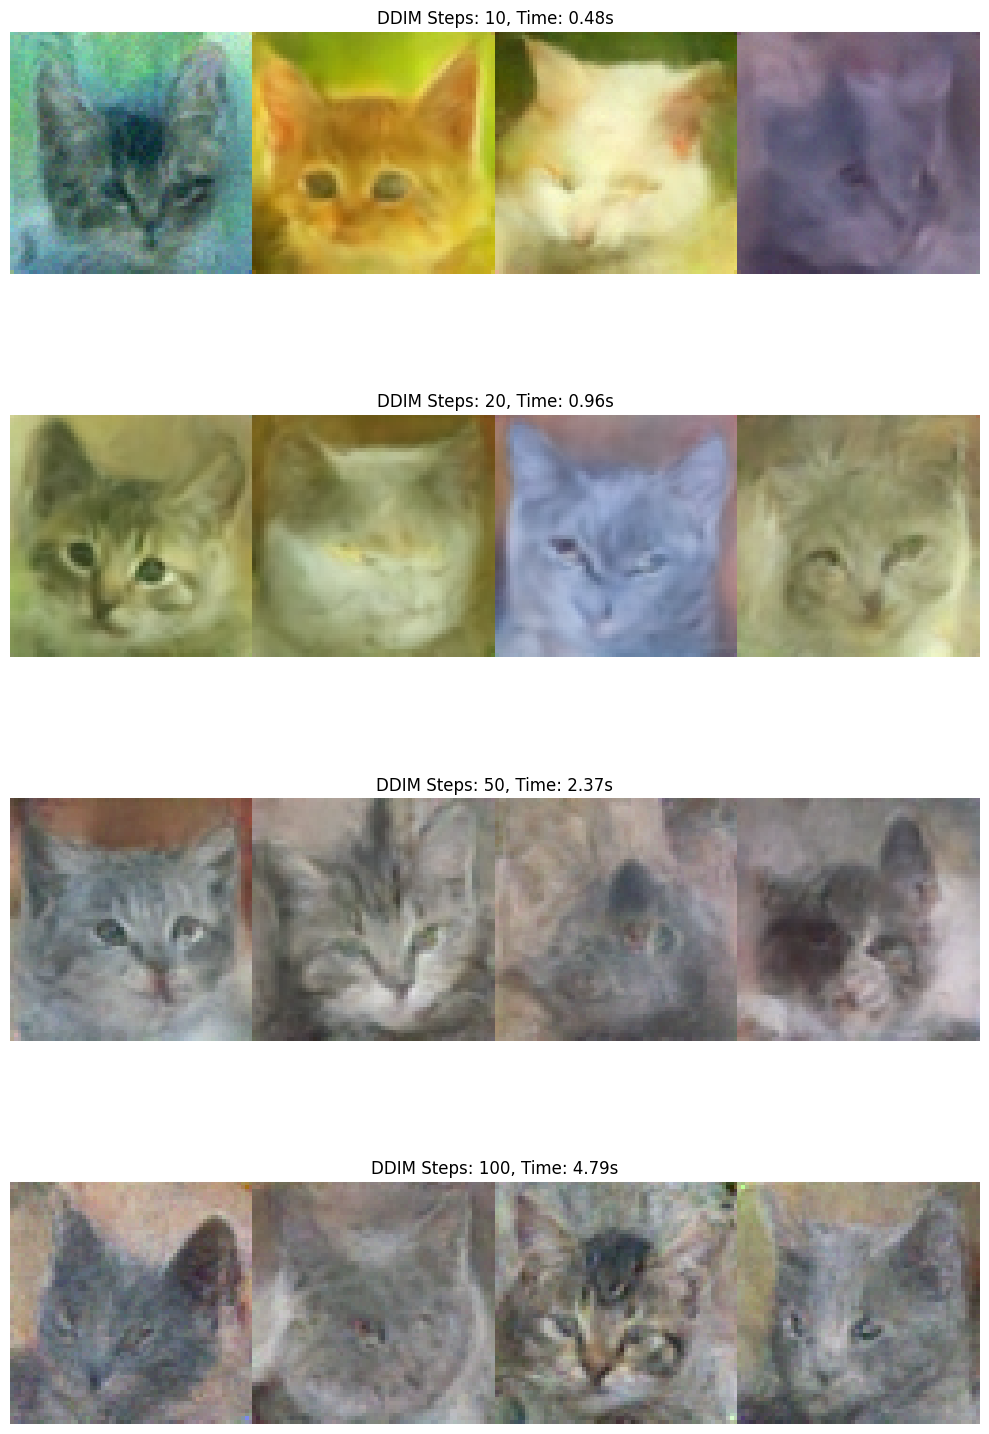

In [7]:
steps_to_test = [10, 20, 50, 100]
results = {}

for steps in steps_to_test:
    print(f"Тестирование DDIM с шагами: {steps}")
    imgs, t = sample_and_time(model, DDIMScheduler, steps, config)
    results[steps] = (imgs, t)

fig, axs = plt.subplots(len(steps_to_test), 1, figsize=(10, 4 * len(steps_to_test)))
for i, steps in enumerate(steps_to_test):
    imgs, t = results[steps]
    # Создание сетки из 4 изображений
    w, h = imgs[0].size
    grid = Image.new("RGB", (4 * w, h))
    for j, img in enumerate(imgs):
        grid.paste(img, (j * w, 0))
    
    axs[i].imshow(grid)
    axs[i].set_title(f"DDIM Steps: {steps}, Time: {t:.2f}s")
    axs[i].axis("off")
plt.tight_layout()
plt.show()

### Эксперимент 2: Влияние расписания шума (Noise Schedule)
Сравним линейное расписание и косинусное (squaredcos_cap_v2).

Тестирование расписания: linear


  0%|          | 0/50 [00:00<?, ?it/s]

Тестирование расписания: squaredcos_cap_v2


  0%|          | 0/50 [00:00<?, ?it/s]

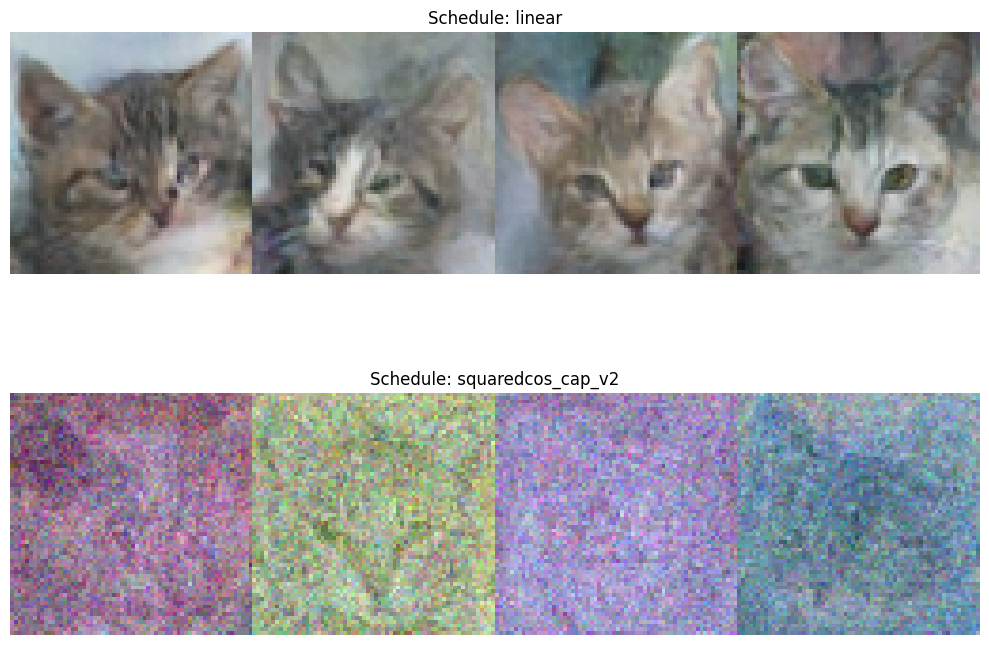

In [8]:
schedules = ["linear", "squaredcos_cap_v2"]
schedule_results = {}

for sched in schedules:
    print(f"Тестирование расписания: {sched}")
    imgs, t = sample_and_time(model, DDIMScheduler, 50, config, beta_schedule=sched)
    schedule_results[sched] = imgs

fig, axs = plt.subplots(len(schedules), 1, figsize=(10, 4 * len(schedules)))
for i, sched in enumerate(schedules):
    imgs = schedule_results[sched]
    w, h = imgs[0].size
    grid = Image.new("RGB", (4 * w, h))
    for j, img in enumerate(imgs):
        grid.paste(img, (j * w, 0))
    
    axs[i].imshow(grid)
    axs[i].set_title(f"Schedule: {sched}")
    axs[i].axis("off")
plt.tight_layout()
plt.show()

### Эксперимент 3: Генерация с условием (Conditioning) выполнить не получится так как нет в датасете нет меток